# Where a steering direction comes from, compared at equal cost

Notebook 07 reproduced the anchor: a training-free logit-lens accuracy predicts which concepts
can be steered, and a trained probe cannot, because it saturates across depth. It also inherited
the anchor's blind spot. The paper never states a dose; it adds the raw difference of means,
whatever norm that happens to have, and then reports that side effect correlates with that norm
at +0.96. So its efficiency numbers compare concepts at unequal doses.

This notebook fixes the dose and asks the question the anchor leaves open: given the same concept,
does it matter where the direction comes from? Three sources -- difference of means, probe weight
vector, SAE decoder row -- plus random directions as a floor, all on unit norm, compared at equal
side effect and at equal effect. Same six families, same seed and same 50 unrelated prompts as 07.


In [1]:
# Setup. Same six families, same 50 unrelated prompts and the same seed as 07, so the numbers here
# plug straight into the anchor reproduction. Four families carry the result (temperature, size,
# pronoun, daynight), parity and continent ride along as floor cases: without a case that fails,
# the go/no-go threshold is not testable.
import json, numpy as np, torch
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from transformer_lens import HookedTransformer
import matplotlib.pyplot as plt
from importlib.metadata import version

SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED); torch.set_grad_enabled(False)
model = HookedTransformer.from_pretrained("gpt2", device="mps")
tok, L, D = model.tokenizer, model.cfg.n_layers, model.cfg.d_model
print(f"gpt2 · {L} layers · d_model {D} · torch {torch.__version__} · "
      f"TL {version('transformer-lens')} · sklearn {version('scikit-learn')}")

ADJ = ["{} is usually very", "{} tends to be very", "{} always feels very"]
ITEMS = {
    "temperature": (["Ice", "Snow", "The Arctic", "Winter", "The freezer", "Frost", "The tundra",
                     "Hail", "Antarctica", "The glacier", "A blizzard", "Sleet"], "cold",
                    ["Fire", "Lava", "The desert", "Summer", "The oven", "Steam", "The sun",
                     "Magma", "The furnace", "A bonfire", "The tropics", "The sauna"], "hot"),
    "size":        (["An ant", "A crumb", "A pebble", "A seed", "A mouse", "A needle", "A button",
                     "A raindrop", "A grain", "A bee", "A coin", "A flea"], "small",
                    ["An elephant", "A whale", "A mountain", "A skyscraper", "A truck", "A castle",
                     "An airplane", "A cathedral", "A stadium", "A glacier", "A warehouse",
                     "A battleship"], "big"),
    "parity":      ([f"The number {n} is" for n in range(3, 39, 2)], "odd",
                    [f"The number {n} is" for n in range(4, 40, 2)], "even"),
    "continent":   ([f"{c} is located in" for c in ["France", "Germany", "Italy", "Spain",
                     "Poland", "Sweden", "Norway", "Portugal", "Austria", "Ireland", "Greece",
                     "Hungary"]], "Europe",
                    [f"{c} is located in" for c in ["Japan", "China", "India", "Thailand",
                     "Vietnam", "Indonesia", "Pakistan", "Nepal", "Cambodia", "Malaysia",
                     "Mongolia", "Laos"]], "Asia"),
}
NAME_TPL = ["When {} arrived at the office,", "{} finished the report, and then",
            "After {} sat down,"]
SHE = ["Mary", "Sarah", "Emma", "Laura", "Anna", "Julia", "Rachel", "Sophie", "Helen", "Alice",
       "Diana", "Emily"]
HE = ["John", "Peter", "Thomas", "Michael", "David", "Robert", "Daniel", "Richard", "Frank",
      "Paul", "Steven", "Brian"]
DAY = ["The sun is out during the", "Sunlight fills the sky during the", "Birds sing during the",
       "Shadows are sharp during the", "People go to work during the", "Traffic is busy during the",
       "Children play outside during the", "The sky is blue during the", "It is warmest during the",
       "Markets are open during the", "Bees gather pollen during the", "Laundry dries during the",
       "Farmers harvest during the", "The beach is crowded during the",
       "Solar panels charge during the", "Offices are full during the"]
NIGHT = ["The stars are out during the", "The moon rises during the", "Owls hunt during the",
         "Streetlights glow during the", "Bats fly during the", "The city is quiet during the",
         "Crickets chirp during the", "The sky is black during the", "It is coldest during the",
         "Bars are open during the", "Nocturnal animals feed during the", "Dreams come during the",
         "Telescopes are used during the", "Nightclubs fill up during the",
         "Fireflies appear during the", "Guards keep watch during the"]

def one_token(word):
    """Billa's design needs single-token answers: the logit lens scores one vocabulary entry."""
    ids = tok.encode(" " + word, add_special_tokens=False)
    assert len(ids) == 1, f"{word!r} is not a single token"
    return ids[0]

FAM = {}
for fname, (a_items, a_word, b_items, b_word) in ITEMS.items():
    build = (lambda xs: [t.format(x) for x in xs for t in ADJ]) if fname in ("temperature", "size")             else (lambda xs: xs)
    FAM[fname] = (build(a_items), one_token(a_word), a_word,
                  build(b_items), one_token(b_word), b_word)
FAM["pronoun"] = ([t.format(n) for n in SHE for t in NAME_TPL], one_token("she"), "she",
                  [t.format(n) for n in HE for t in NAME_TPL], one_token("he"), "he")
FAM["daynight"] = (DAY, one_token("day"), "day", NIGHT, one_token("night"), "night")

# 50 unrelated prompts: the side-effect measure. Billa uses KL on 50 unrelated prompts, so the
# only requirement is that none of them is about any of the six concepts.
UNRELATED = ["The committee agreed that the proposal", "In 1965 the company decided to",
    "She opened the letter and read", "The engine failed because the", "According to the report,",
    "He walked into the library and", "The price of copper has", "Researchers at the university",
    "The train left the station before", "Most of the audience had already",
    "After the meeting ended, the", "The software update introduced", "Critics argued that the film",
    "The bridge was built in", "Her argument rested on the", "The document was signed by",
    "A spokesperson confirmed that", "The council voted to", "Sales figures for the quarter",
    "The professor handed back the", "Negotiations broke down when", "The map showed that the",
    "Investors responded to the news by", "The recipe calls for two", "His colleagues described him as",
    "The museum acquired the painting", "Local farmers complained about", "The judge ruled that the",
    "Traffic on the highway was", "The archive contains letters from", "She had studied law before",
    "The experiment was repeated with", "Members of the union demanded", "The novel begins with a",
    "Officials denied that the", "The camera was mounted on", "Analysts expect the market to",
    "The letter arrived three weeks", "He learned to play the", "The building was designed by",
    "Passengers waited for hours while", "The survey found that most", "Her first job was at a",
    "The machine stopped working after", "Delegates from twelve countries", "The article claimed that",
    "Rain delayed the start of", "The library closes at", "Workers began removing the",
    "The contract was renewed for"]

def batch(prompts):
    """gpt2 has no pad token and its BOS equals its EOS, so true lengths are kept explicitly."""
    seqs = [model.to_tokens(p)[0] for p in prompts]
    last = torch.tensor([len(s) - 1 for s in seqs], device=model.cfg.device)
    w = max(len(s) for s in seqs)
    ids = torch.stack([torch.cat([s, s.new_full((w - len(s),), tok.eos_token_id)]) for s in seqs])
    return ids.to(model.cfg.device), last

for f, (pa, _, wa, pb, _, wb) in FAM.items():
    print(f"{f:<12} n = {len(pa):>2} ' {wa}' + {len(pb):>2} ' {wb}'")
print(f"{'unrelated':<12} n = {len(UNRELATED)}")

def resid_at_last(prompts):
    """Residual stream at the last prompt position, all layers at once -- one forward pass."""
    ids, last = batch(prompts)
    _, cache = model.run_with_cache(ids, return_type=None)
    idx = torch.arange(len(prompts), device=model.cfg.device)
    out = torch.stack([cache[f"blocks.{l}.hook_resid_post"][idx, last] for l in range(L)])
    del cache
    return out  # [layer, prompt, d_model]

def lens(h):
    """The logit lens is the model's own head: fold-equivalent final layer norm, then unembed."""
    return model.unembed(model.ln_final(h[:, None]))[:, 0]

# The SAEs in jbloom/GPT2-Small-SAEs-Reformatted sit on hook_resid_pre, this notebook measures on
# hook_resid_post. Checked against the cache: blocks.{l+1}.hook_resid_pre is bit-identical to
# blocks.{l}.hook_resid_post, so folder l+1 is the right SAE for layer l -- and layer 11 has none,
# which matters because that is where A_lin peaks.
SAE_LAYERS = list(range(L - 1))  # 0..10
SAE_REPO = "jbloom/GPT2-Small-SAEs-Reformatted"


/Users/Brose/dev/private_repos/mechinterp_xai/.venv/lib/python3.13/site-packages/transformer_lens/config/hooked_transformer_config.py:354: UserWarning: MPS backend may produce silently incorrect results (PyTorch 2.13.0). Set TRANSFORMERLENS_ALLOW_MPS=1 to suppress this warning. See: https://github.com/TransformerLensOrg/TransformerLens/issues/1178
  warn_if_mps(self.device)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
gpt2 · 12 layers · d_model 768 · torch 2.13.0 · TL 3.5.1 · sklearn 1.9.1
temperature  n = 36 ' cold' + 36 ' hot'
size         n = 36 ' small' + 36 ' big'
parity       n = 18 ' odd' + 18 ' even'
continent    n = 12 ' Europe' + 12 ' Asia'
pronoun      n = 36 ' she' + 36 ' he'
daynight     n = 16 ' day' + 16 ' night'
unrelated    n = 50


The reading axis first, because two of the three sources are reading tools before they
are steering tools. The discipline: the direction gets fitted on everything, the reported quality
is measured on a held-out quarter, and all fitted measures share one split per family.


In [2]:
# Reading axis and the first two direction sources in one pass. A difference of means and a probe
# weight vector are each both a reading measure and a steering direction -- that double role is the
# experiment. Discipline: the direction is fitted on everything (more data, better direction), the
# reported quality is measured on a held-out quarter, and every fitted measure shares one split per
# family so the numbers carry the same optimism. A_lin needs no fit at all.
from sklearn.metrics import roc_auc_score

acts, split = {}, {}
for f, (pa, _, _, pb, _, _) in FAM.items():
    acts[f] = (resid_at_last(pa), resid_at_last(pb))
    n = len(pa) + len(pb)
    perm = np.random.default_rng(SEED).permutation(n)
    split[f] = (perm[:int(0.75 * n)], perm[int(0.75 * n):])

def xy(f, layer):
    ha, hb = acts[f]
    X = torch.cat([ha[layer], hb[layer]]).float().cpu().numpy()
    return X, np.r_[np.ones(ha.shape[1]), np.zeros(hb.shape[1])]

alin, probe_acc, auroc_mean, d_mean, w_probe = {}, {}, {}, {}, {}
for f, (pa, ta, _, pb, tb, _) in FAM.items():
    ha, hb = acts[f]
    tr, te = split[f]
    n = len(pa) + len(pb)
    alin[f] = [((lens(ha[l]).argmax(-1) == ta).sum() + (lens(hb[l]).argmax(-1) == tb).sum()).item() / n
               for l in range(L)]
    probe_acc[f], auroc_mean[f], d_mean[f], w_probe[f] = [], [], [], []
    for l in range(L):
        X, y = xy(f, l)
        fit = LogisticRegression(max_iter=2000, C=1.0).fit(X[tr], y[tr])
        probe_acc[f].append(fit.score(X[te], y[te]))
        # difference of means from the training half only, scored on the held-out quarter
        d_tr = X[tr][y[tr] == 1].mean(0) - X[tr][y[tr] == 0].mean(0)
        auroc_mean[f].append(roc_auc_score(y[te], X[te] @ d_tr))
        d_mean[f].append(torch.tensor(X[y == 1].mean(0) - X[y == 0].mean(0), device=model.cfg.device))
        w_probe[f].append(torch.tensor(
            LogisticRegression(max_iter=2000, C=1.0).fit(X, y).coef_[0], device=model.cfg.device).float())

# One dose scale per layer: the mean residual norm over all positions of the 50 unrelated prompts.
# Residual norms in gpt2 grow steeply with depth, so a fixed absolute dose is an earthquake in L1
# and a rounding error in L11. Relative dosing is what makes layers comparable at all -- and it is
# the one number Billa never states.
unrel_ids, unrel_last = batch(UNRELATED)
_, ucache = model.run_with_cache(unrel_ids, return_type=None)
resnorm = [ucache[f"blocks.{l}.hook_resid_post"].norm(dim=-1).mean().item() for l in range(L)]
del ucache

print("mean residual norm per layer (the dose unit):")
print("  " + " ".join(f"L{l}:{resnorm[l]:.0f}" for l in range(L)))
print("\nreading, three measures per family at the layer where each peaks")
print(f"{'family':<12} {'A_lin':>16} {'probe (held out)':>22} {'AUROC diff-of-means':>24}")
for f in FAM:
    a, p, u = alin[f], probe_acc[f], auroc_mean[f]
    print(f"{f:<12} {max(a):>9.3f} @L{int(np.argmax(a)):<3} {max(p):>15.3f} @L{int(np.argmax(p)):<3} "
          f"{max(u):>17.3f} @L{int(np.argmax(u)):<3}")
print("\ncos(diff-of-means, probe weights) per layer -- two ways to the same concept:")
for f in FAM:
    cs = [torch.nn.functional.cosine_similarity(d_mean[f][l], w_probe[f][l], dim=0).item() for l in range(L)]
    print(f"  {f:<12} " + " ".join(f"{c:>+5.2f}" for c in cs))


mean residual norm per layer (the dose unit):
  L0:76 L1:135 L2:383 L3:411 L4:440 L5:457 L6:475 L7:497 L8:518 L9:555 L10:644 L11:489

reading, three measures per family at the layer where each peaks
family                  A_lin       probe (held out)      AUROC diff-of-means
temperature      0.681 @L11            1.000 @L10              0.740 @L11 
size             0.250 @L11            1.000 @L0               1.000 @L0  
parity           0.000 @L0             0.889 @L4               1.000 @L0  
continent        0.042 @L9             1.000 @L0               1.000 @L2  
pronoun          0.986 @L11            1.000 @L0               1.000 @L10 
daynight         0.312 @L11            0.750 @L5               0.733 @L11 

cos(diff-of-means, probe weights) per layer -- two ways to the same concept:
  temperature  +0.88 +0.82 +0.70 +0.68 +0.67 +0.63 +0.57 +0.62 +0.60 +0.61 +0.66 +0.63
  size         +0.86 +0.91 +0.94 +0.93 +0.87 +0.87 +0.83 +0.79 +0.76 +0.78 +0.77 +0.78
  parity       +0.95 

Two things stand out, and neither is about steering yet. Residual norms grow by a
factor of eight across depth, so an absolute dose would mean something different in every layer --
dosing relative to the layer's own norm is what makes layers comparable at all. And the fitted
measures are perfect at layer 0, where the residual stream is nothing but embedding plus position:
at L0 they read the token, not the concept. `parity` shows the failure mode in pure form, AUROC
1.00 while the model cannot answer the question at all.

Before trusting the SAE as a direction source, the check from Tiwari et al.: split each activation
into its SAE reconstruction and the error, project both onto the reading direction, and ask what
share of the class separation ends up in the error. They found 74% there for Qwen3-8B. Note this is
reported as a finding, not used as a gate -- we add a decoder row to the real residual stream and
read the effect off the model itself, so the measurement is valid either way. What the share
decides is whether "the SAE found the concept" is a fair sentence.


In [3]:
# The SAE layer: substrate check and feature search in one pass over the eleven available SAEs.
# Substrate check after Tiwari: split h into its reconstruction and the error, project both on the
# probe direction, and ask what share of the class separation lives in the error. Their Qwen case
# had 74% there -- an ablation inside the SAE basis would then be measuring the SAE, not the model.
# Reported as a finding, not used as a gate: we ADD a decoder row to the real residual stream and
# read the effect off the model itself, so the measurement stands on its own. The share tells us
# whether "the SAE found the concept" is a fair sentence, which is a claim about meaning, not about
# the validity of the number.
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file

def separation(vecs_a, vecs_b, direction):
    """Class separation along one direction -- linear, so it splits additively over h = rec + err."""
    u = direction / direction.norm()
    return ((vecs_a @ u).mean() - (vecs_b @ u).mean()).item()

def pick_feature(fa, fb, tr_a, tr_b):
    """Selected on the training half only. Criterion fixed before looking, as in station 5: the
    feature must fire on at least 60% of one class and at most 25% of the other -- one that fires
    everywhere separates by magnitude and is no detector. Sign fixed to class A, because the
    intervention has to push B prompts toward answer A; a B detector added negatively is a
    different object, not the same direction reversed."""
    delta = fa[tr_a].mean(0) - fb[tr_b].mean(0)
    rate_a, rate_b = (fa[tr_a] > 0).float().mean(0), (fb[tr_b] > 0).float().mean(0)
    ok = (rate_a >= 0.6) & (rate_b <= 0.25) & (delta > 0)
    if ok.any():
        score = torch.where(ok, delta, torch.full_like(delta, -1e9))
        return int(score.argmax()), int(ok.sum()), True
    return int(delta.argmax()), 0, False  # nothing passes: report the fallback as such

sae_share, sae_ev, sae_acc, d_sae, auroc_sae, sae_pick = {}, {}, {}, {}, {}, {}
for f in FAM:
    for k in (sae_share, sae_ev, sae_acc, d_sae, auroc_sae, sae_pick):
        k[f] = {}

clean_out = {}
for f, (pa, ta, _, pb, tb, _) in FAM.items():
    ids_a, last_a = batch(pa); ids_b, last_b = batch(pb)
    ia = torch.arange(len(pa), device=model.cfg.device); ib = torch.arange(len(pb), device=model.cfg.device)
    la = model(ids_a)[ia, last_a]; lb = model(ids_b)[ib, last_b]
    clean_out[f] = ((la.argmax(-1) == ta).float().mean().item() + (lb.argmax(-1) == tb).float().mean().item()) / 2

for l in SAE_LAYERS:
    w = load_file(hf_hub_download(SAE_REPO, filename=f"blocks.{l+1}.hook_resid_pre/sae_weights.safetensors"))
    W_enc, b_enc, W_dec, b_dec = (w[k].to(model.cfg.device) for k in ("W_enc", "b_enc", "W_dec", "b_dec"))
    encode = lambda x: torch.relu((x - b_dec) @ W_enc + b_enc)
    recon = lambda x: encode(x) @ W_dec + b_dec

    for f, (pa, ta, _, pb, tb, _) in FAM.items():
        ha, hb = acts[f][0][l], acts[f][1][l]
        na = ha.shape[0]
        tr, te = split[f]
        tr_a, tr_b = tr[tr < na], tr[tr >= na] - na
        te_a, te_b = te[te < na], te[te >= na] - na

        ra, rb = recon(ha), recon(hb)
        ea, eb = ha - ra, hb - rb
        h_all = torch.cat([ha, hb]); e_all = torch.cat([ea, eb])
        sae_ev[f][l] = (1 - e_all.var() / h_all.var()).item()

        share = {}
        for nm, direction in (("probe", w_probe[f][l]), ("diffmeans", d_mean[f][l])):
            s_h = separation(ha, hb, direction)
            s_e = separation(ea, eb, direction)
            share[nm] = s_e / s_h if abs(s_h) > 1e-9 else float("nan")
        sae_share[f][l] = share

        # model-facing variant: replace the layer with its own reconstruction and see if the answer
        # survives. Explained variance is a statement about the vector, this one about the behaviour.
        hook = [(f"blocks.{l}.hook_resid_post", lambda act, hook: recon(act))]
        with model.hooks(fwd_hooks=hook):
            ids_a, last_a = batch(pa); ids_b, last_b = batch(pb)
            ia = torch.arange(len(pa), device=model.cfg.device)
            ib = torch.arange(len(pb), device=model.cfg.device)
            aa = (model(ids_a)[ia, last_a].argmax(-1) == ta).float().mean().item()
            ab = (model(ids_b)[ib, last_b].argmax(-1) == tb).float().mean().item()
        sae_acc[f][l] = (aa + ab) / 2

        fa, fb = encode(ha), encode(hb)
        idx, n_ok, passed = pick_feature(fa, fb, tr_a, tr_b)
        sae_pick[f][l] = (idx, n_ok, passed)
        d_sae[f][l] = W_dec[idx].clone()
        y_te = np.r_[np.ones(len(te_a)), np.zeros(len(te_b))]
        s_te = torch.cat([fa[te_a, idx], fb[te_b, idx]]).float().cpu().numpy()
        auroc_sae[f][l] = roc_auc_score(y_te, s_te) if len(set(y_te)) > 1 else float("nan")
    del W_enc, b_enc, W_dec, b_dec, w
    print(f"L{l} done", end="  ", flush=True)

print("\n\nsubstrate check -- share of the reading separation that sits in the reconstruction error")
print(f"{'family':<12} " + " ".join(f"{'L'+str(l):>6}" for l in SAE_LAYERS))
for f in FAM:
    print(f"{f:<12} " + " ".join(f"{sae_share[f][l]['probe']:>6.2f}" for l in SAE_LAYERS))
print("\nexplained variance of the reconstruction")
for f in FAM:
    print(f"{f:<12} " + " ".join(f"{sae_ev[f][l]:>6.2f}" for l in SAE_LAYERS))
print("\nmodel answer accuracy with that layer replaced by its reconstruction (clean value first)")
for f in FAM:
    print(f"{f:<12} {clean_out[f]:>5.2f} | " + " ".join(f"{sae_acc[f][l]:>6.2f}" for l in SAE_LAYERS))
print("\nchosen feature per family (at L6 and L10, the two sweep layers)")
for f in FAM:
    for l in (6, 10):
        idx, n_ok, passed = sae_pick[f][l]
        tag = f"{n_ok} pass criterion" if passed else "NOTHING passes -- fallback to largest gap"
        print(f"  {f:<12} L{l:<3} feature {idx:>6}  AUROC(held out) {auroc_sae[f][l]:.2f}  {tag}")


L0 done  

L1 done  

L2 done  

L3 done  

L4 done  

...

L7 done  

L8 done  

L9 done  

L10 done  



substrate check -- share of the reading separation that sits in the reconstruction error
family           L0     L1     L2     L3     L4     L5     L6     L7     L8     L9    L10
temperature    0.94   0.91   0.89   0.94   0.88   0.87   0.81   0.74   0.62   0.62   0.58
size           0.92   0.90   0.79   0.73   0.68   0.65   0.63   0.67   0.54   0.56   0.56
parity         0.86   0.84   0.91   0.77   0.71   0.84   0.80   0.73   0.72   0.81   0.80
continent      0.74   0.85   0.82   0.72   0.68   0.76   0.73   0.71   0.76   0.52   0.47
pronoun        0.92   0.82   0.77   0.79   0.79   0.77   0.61   0.66   0.52   0.50   0.35
daynight       0.99   0.94   0.85   0.82   0.80   0.80   0.69   0.72   0.68   0.73   0.71

explained variance of the reconstruction
temperature    0.99   0.99   0.98   0.97   0.96   0.96   0.95   0.95   0.94   0.93   0.94
size           0.99   0.99   0.98   0.97   0.96   0.96   0.95   0.94   0.95   0.93   0.95
parity         0.99   0.99   0.98   0.96   0.95   0.94   

The substrate check lands harder than expected. The reconstruction explains 93-99% of the
variance -- excellent by the usual SAE metric -- while 35 to 99% of the concept separation sits in
the error it throws away. Tiwari's 74% reproduces almost exactly in the middle layers, on a
different model, a different SAE and different concepts. The share falls with depth, so these SAEs
only catch the concepts late. And replacing a layer with its own reconstruction costs the model its
answer: `temperature` falls from 0.68 to 0.35, `daynight` from 0.31 to 0.09, at 94% explained
variance. The feature search agrees -- at L6 nothing passes the criterion for four of six families.

Now the four sources side by side. If they turned out to be the same direction written three ways,
there would be nothing left to compare.


In [4]:
# The four direction sources, all on unit norm so that dose is the only scale left. That is the
# whole point of the comparison: Billa's efficiency numbers compare concepts whose raw differences
# of means have norms from 2.4 to 149, and he reports rho(||d||, KL) = +0.96 -- so his side-effect
# axis is mostly the norm he never states. Unit norm plus an explicit relative dose removes that.
# The floor is five random unit directions instead of one, and the MAXIMUM of the five is the floor
# we report: a single random draw that happens to do nothing is not evidence of a floor.
SOURCES = ["diffmeans", "probe", "sae", "random"]
RAND = [torch.nn.functional.normalize(torch.randn(D, generator=torch.Generator().manual_seed(s)), dim=0
        ).to(model.cfg.device) for s in range(5)]

def direction(f, layer, src, k=0):
    if src == "diffmeans": v = d_mean[f][layer]
    elif src == "probe":   v = w_probe[f][layer]
    elif src == "sae":     v = d_sae[f][layer] if layer in SAE_LAYERS else None
    else:                  v = RAND[k]
    return None if v is None else v / v.norm()

clean_unrel = model(unrel_ids)[torch.arange(len(UNRELATED), device=model.cfg.device), unrel_last].log_softmax(-1)
clean_b = {}
for f, (pa, ta, _, pb, tb, _) in FAM.items():
    ids_b, last_b = batch(pb)
    ib = torch.arange(len(pb), device=model.cfg.device)
    clean_b[f] = model(ids_b)[ib, last_b].softmax(-1)[:, ta].mean().item()

def steer(f, layer, u, alpha):
    """Add alpha * (mean residual norm of that layer) * u at every prompt position of the class-B
    prompts, the same intervention form as in 07. Effect: change in P(answer A). Side effect: KL on
    the 50 unrelated prompts under the identical intervention."""
    pa, ta, _, pb, tb, _ = FAM[f]
    v = (alpha * resnorm[layer]) * u
    hooks = [(f"blocks.{layer}.hook_resid_post", lambda act, hook: act + v)]
    ids_b, last_b = batch(pb)
    ib = torch.arange(len(pb), device=model.cfg.device)
    iu = torch.arange(len(UNRELATED), device=model.cfg.device)
    with model.hooks(fwd_hooks=hooks):
        p = model(ids_b)[ib, last_b].softmax(-1)[:, ta].mean().item()
        sl = model(unrel_ids)[iu, unrel_last].log_softmax(-1)
    kl = torch.nn.functional.kl_div(sl, clean_unrel, log_target=True, reduction="batchmean").item()
    return p - clean_b[f], kl

print("cos between the sources at the two sweep layers -- if they were the same direction there")
print("would be nothing to compare")
for l in (6, 10):
    print(f"\nL{l}  {'family':<12} {'d/probe':>9} {'d/sae':>9} {'probe/sae':>11} {'d/random':>10}")
    for f in FAM:
        u = {s: direction(f, l, s) for s in SOURCES}
        cs = lambda a, b: torch.nn.functional.cosine_similarity(a, b, dim=0).item()
        print(f"    {f:<12} {cs(u['diffmeans'], u['probe']):>+9.2f} {cs(u['diffmeans'], u['sae']):>+9.2f} "
              f"{cs(u['probe'], u['sae']):>+11.2f} {cs(u['diffmeans'], u['random']):>+10.2f}")


cos between the sources at the two sweep layers -- if they were the same direction there
would be nothing to compare

L6  family         d/probe     d/sae   probe/sae   d/random
    temperature      +0.57     +0.09       +0.08      +0.02
    size             +0.83     +0.22       +0.19      -0.01
    parity           +0.88     +0.04       +0.03      +0.03
    continent        +0.88     +0.07       +0.09      +0.02
    pronoun          +0.97     +0.67       +0.66      +0.02
    daynight         +0.72     +0.31       +0.14      +0.04

L10  family         d/probe     d/sae   probe/sae   d/random
    temperature      +0.66     +0.50       +0.46      +0.02
    size             +0.77     +0.26       +0.21      +0.01
    parity           +0.78     +0.25       +0.18      -0.01
    continent        +0.95     +0.41       +0.43      -0.01
    pronoun          +0.96     +0.53       +0.61      +0.06
    daynight         +0.62     +0.32       +0.08      -0.03


They are not the same direction. The probe and the difference of means run from cos +0.57
to +0.97, and the SAE row is nearly orthogonal to both at L6 -- consistent with the feature search
finding nothing there. Coverage next: all four sources at every layer, at one fixed dose.


In [5]:
# Coverage first: all four sources at every layer, at one fixed reference dose. The dose 0.1 comes
# from a calibration sweep -- effect is measurable there and the model is still intact, while from
# 0.4 upward every direction only destroys (KL > 2, effect collapsing). One dose per cell keeps this
# readable; the equal-effect comparison follows in the next cell on two layers.
# The SAE row stops at L10: the released SAEs sit on hook_resid_pre of blocks 0-11, which is
# resid_post of layers -1 to 10. Layer 11 has none -- and that is where A_lin peaks for all four
# carrying families, so the gap is a result, not a detail.
import time
REF = 0.1
t0 = time.time()
scan = {f: {s: [None] * L for s in SOURCES} for f in FAM}
for f in FAM:
    for l in range(L):
        for s in SOURCES:
            if s == "random":
                runs = [steer(f, l, direction(f, l, s, k), REF) for k in range(len(RAND))]
                scan[f][s][l] = max(runs, key=lambda r: r[0])  # the best of five is the floor
            else:
                u = direction(f, l, s)
                scan[f][s][l] = None if u is None else steer(f, l, u, REF)
print(f"scan done in {time.time()-t0:.0f}s\n")

fmt = lambda r: "   --  " if r is None else f"{r[0]:>+7.3f}"
print(f"dP at dose {REF} of the layer's mean residual norm")
for s in SOURCES:
    print(f"\n{s}")
    print(f"{'family':<12} " + " ".join(f"{'L'+str(l):>7}" for l in range(L)))
    for f in FAM:
        print(f"{f:<12} " + " ".join(fmt(scan[f][s][l]) for l in range(L)))

print(f"\nbest layer per family and source at this dose (dP, KL there)")
print(f"{'family':<12} " + " ".join(f"{s:>22}" for s in SOURCES))
for f in FAM:
    cells = []
    for s in SOURCES:
        vals = [(l, r) for l, r in enumerate(scan[f][s]) if r is not None]
        l, (dp, kl) = max(vals, key=lambda x: x[1][0])
        cells.append(f"{dp:>+7.3f} @L{l:<2} KL {kl:>5.2f}")
    print(f"{f:<12} " + " ".join(f"{c:>22}" for c in cells))


scan done in 72s

dP at dose 0.1 of the layer's mean residual norm

diffmeans
family            L0      L1      L2      L3      L4      L5      L6      L7      L8      L9     L10     L11
temperature   +0.007  +0.022  +0.030  +0.085  -0.028  -0.031  +0.011  +0.012  -0.007  +0.053  +0.190  +0.113
size          +0.000  -0.003  -0.029  -0.023  +0.051  +0.113  +0.376  +0.092  +0.069  +0.036  +0.023  +0.012
parity        +0.000  +0.000  +0.000  -0.000  +0.000  -0.000  -0.000  -0.000  -0.000  -0.000  +0.000  +0.000
continent     +0.000  +0.002  +0.011  +0.018  +0.032  +0.043  +0.063  +0.031  +0.026  +0.009  +0.010  +0.008
pronoun       +0.001  +0.023  +0.197  +0.321  +0.240  +0.172  +0.189  +0.260  +0.286  +0.315  +0.336  +0.320
daynight      -0.002  +0.012  +0.029  -0.008  +0.216  +0.091  +0.086  +0.049  +0.017  +0.054  +0.055  +0.051

probe
family            L0      L1      L2      L3      L4      L5      L6      L7      L8      L9     L10     L11
temperature   +0.011  +0.030  +0.177  +0.22

At a fixed dose the picture looks like a demolition of the anchor. `size` goes from
last place to first, +0.019 in 07 against +0.376 here, and the family ranking no longer matches
`A_lin` at all. But a fixed dose is not a fair comparison either: `size` at L6 costs KL 0.79 while
`pronoun` at L10 costs 0.14. Two other things are already visible -- `parity` is exactly 0.000 for
all four sources in all twelve layers, and a random direction reaches +0.098 on `daynight`, more
than the SAE row manages anywhere.

So the comparison has to be made at equal cost. Full dose sweep, then read off at a fixed side
effect and at a fixed effect.


In [6]:
# The comparison the anchor does not make: every source through a full dose sweep, then read off
# at equal side effect and at equal effect instead of at whatever dose the vector happened to have.
# Two layers: L6 is the middle-layer heuristic everyone reaches for, L10 is the deepest layer with
# an SAE. Targets fixed before looking -- KL* = 0.1 nats and dP* = +0.05 -- both well inside the
# measured range, so neither favours a source by construction.
DOSES = [0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3, 0.4]
KL_STAR, DP_STAR = 0.1, 0.05
SWEEP_LAYERS = [6, 10]

t0 = time.time()
sweep = {}
for f in FAM:
    for l in SWEEP_LAYERS:
        for s in SOURCES:
            u = direction(f, l, s)
            if u is None:
                sweep[f, l, s] = None
                continue
            if s == "random":
                sweep[f, l, s] = [max((steer(f, l, direction(f, l, s, k), a) for k in range(3)),
                                      key=lambda r: r[0]) for a in DOSES]
            else:
                sweep[f, l, s] = [steer(f, l, u, a) for a in DOSES]
print(f"sweep done in {time.time()-t0:.0f}s ({len(sweep)} curves x {len(DOSES)} doses)\n")

def dp_at_kl(curve, target):
    """KL rises monotonically with dose, so the curve can be inverted: interpolate the effect in
    log KL at the given side-effect budget. Outside the measured range we report nothing rather
    than extrapolating."""
    kls = [k for _, k in curve]
    for i in range(len(curve) - 1):
        if kls[i] <= target <= kls[i + 1]:
            w = (np.log(target) - np.log(kls[i])) / (np.log(kls[i + 1]) - np.log(kls[i]))
            return curve[i][0] + w * (curve[i + 1][0] - curve[i][0])
    return None

def kl_at_dp(curve, target):
    """Cheapest dose that reaches the target effect: the first crossing on the rising branch. The
    effect is not monotone -- it collapses once the model breaks -- so a last crossing would be
    meaningless."""
    for i in range(len(curve) - 1):
        if curve[i][0] < target <= curve[i + 1][0]:
            w = (target - curve[i][0]) / (curve[i + 1][0] - curve[i][0])
            return curve[i][1] + w * (curve[i + 1][1] - curve[i][1])
    return None

cell = lambda v, p=3: "   n/r " if v is None else f"{v:>+7.{p}f}"
for l in SWEEP_LAYERS:
    print(f"L{l}: effect at equal side effect (dP at KL = {KL_STAR}) | cost at equal effect "
          f"(KL at dP = {DP_STAR:+})")
    print(f"{'family':<12} " + " ".join(f"{s:>17}" for s in SOURCES))
    for f in FAM:
        cells = []
        for s in SOURCES:
            c = sweep[f, l, s]
            if c is None:
                cells.append("      no SAE     ")
            else:
                cells.append(f"{cell(dp_at_kl(c, KL_STAR))} |{cell(kl_at_dp(c, DP_STAR), 2)[1:]}")
        print(f"{f:<12} " + " ".join(f"{c:>17}" for c in cells))
    print()

print("n/r = not reached inside the measured dose range (0.01 to 0.4 of the residual norm)")
print(f"\nrank order of the four carrying families, three ways of asking:")
carry = ["pronoun", "temperature", "daynight", "size"]
by_alin = sorted(carry, key=lambda f: -max(alin[f]))
by_dose = sorted(carry, key=lambda f: -max(max(r[0] for r in sweep[f, l, "diffmeans"]) for l in SWEEP_LAYERS))
by_kl = sorted(carry, key=lambda f: -max((dp_at_kl(sweep[f, l, "diffmeans"], KL_STAR) or -9)
                                         for l in SWEEP_LAYERS))
print(f"  by peak A_lin (the anchor's predictor): {' > '.join(by_alin)}")
print(f"  by best dP at any dose:                 {' > '.join(by_dose)}")
print(f"  by dP at equal KL budget:               {' > '.join(by_kl)}")


sweep done in 98s (48 curves x 10 doses)

L6: effect at equal side effect (dP at KL = 0.1) | cost at equal effect (KL at dP = +0.05)
family               diffmeans             probe               sae            random
temperature     +0.023 |  n/r     +0.109 | +0.03    +0.014 |  n/r     +0.015 |  n/r 
size            +0.075 | +0.07    +0.022 | +0.24    +0.002 |  n/r     +0.039 |  n/r 
parity          -0.000 |  n/r     -0.000 |  n/r     -0.000 |  n/r     +0.000 |  n/r 
continent       +0.023 | +0.21    +0.011 |  n/r     -0.000 |  n/r     +0.000 |  n/r 
pronoun         +0.263 |  n/r     +0.260 |  n/r     +0.245 |  n/r     +0.008 |  n/r 
daynight        +0.021 | +0.31    +0.005 |  n/r     -0.038 |  n/r     +0.051 | +0.10

L10: effect at equal side effect (dP at KL = 0.1) | cost at equal effect (KL at dP = +0.05)
family               diffmeans             probe               sae            random
temperature     +0.130 | +0.02    +0.156 | +0.01    +0.175 | +0.01    +0.017 |  n/r 
size     

That settles it, and less dramatically than the fixed-dose view suggested. At an
equal KL budget the ranking is `pronoun` > `temperature` > `size` > `daynight` against `A_lin`'s
prediction of `pronoun` > `temperature` > `daynight` > `size`: one adjacent swap, so the anchor's
predictor mostly survives a comparison it never made. The collapse at equal dose was a dose
artifact, which is the more interesting result -- the perfect correlation in 07 was partly bought
with the dose the norm happened to supply.

Two results cut the other way. On `daynight` at L6 a random direction beats all three principled
sources and reaches the target effect at a third of the side effect. And on `temperature` at L10 the
SAE row wins, where Billa's untested prediction says it should add nothing. The last cell puts
numbers on all three questions.


within family, across layers, at the fixed dose 0.1 (Spearman against dP of the
difference-of-means direction -- the source the anchor uses):
family            A_lin   probe acc    AUROC d   AUROC sae
temperature      +0.562      +0.616     +0.507      +0.411
size             -0.101      +0.044     -0.206      -0.200
parity         constant      -0.258     -0.359      -0.348
continent        -0.218    constant     +0.648      -0.396
pronoun          +0.541    constant     +0.686      +0.674
daynight         +0.239      +0.490     +0.000      +0.324

source against the random floor, at equal side effect (dP at KL = 0.1):
family        layer  diffmeans      probe        sae     random   beats floor?
temperature      L6     +0.023     +0.109     +0.014     +0.015   diffmeans, probe
temperature     L10     +0.130     +0.156     +0.175     +0.017   diffmeans, probe, sae
size             L6     +0.075     +0.022     +0.002     +0.039   diffmeans
size            L10     +0.015     -0.015     

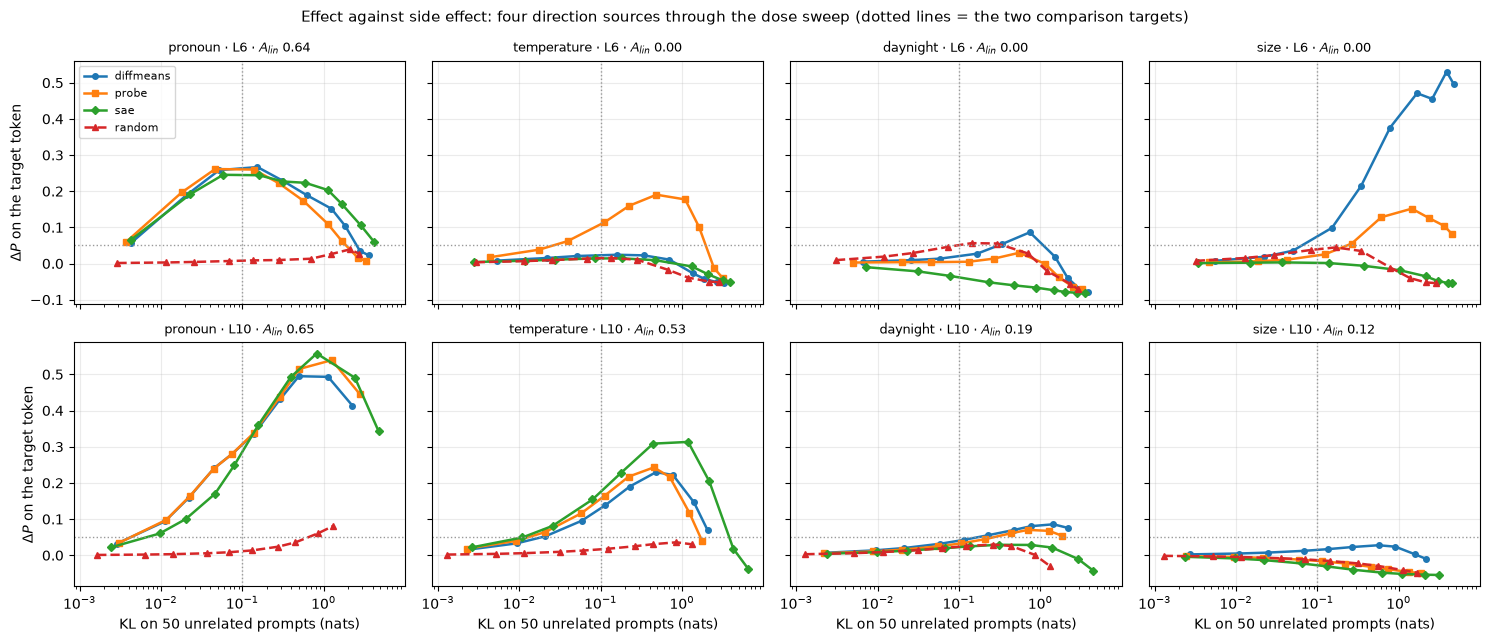


numbers written to results/08_direction_sources.json


In [7]:
# The three questions this grid was built for.
# (1) Which reading measure predicts steering across layers, once dose is held fixed? 07 answered
#     this at the anchor's implicit dose; here the dose is the same for every layer.
# (2) Does each source beat the random floor at all? A source that does not is not a method.
# (3) Billa's untested SAE prediction for regime 3: where A_lin is high the concept is already
#     output-aligned, so an SAE feature should add little. Regime 2 is only weakly addressable
#     here -- we dropped A_mlp, so "present but not linearly readable" rests on the probe, and a
#     failing probe never proves absence.
from scipy.stats import spearmanr

def rho(x, y):
    """Flat input has no rank order to correlate. Saying so is the finding, not a NaN."""
    return "constant" if len(set(x)) == 1 else f"{spearmanr(x, y).statistic:+.3f}"

dp_scan = {f: {s: [None if r is None else r[0] for r in scan[f][s]] for s in SOURCES} for f in FAM}
print(f"within family, across layers, at the fixed dose {REF} (Spearman against dP of the")
print("difference-of-means direction -- the source the anchor uses):")
print(f"{'family':<12} {'A_lin':>10} {'probe acc':>11} {'AUROC d':>10} {'AUROC sae':>11}")
for f in FAM:
    y = dp_scan[f]["diffmeans"]
    ys = [y[l] for l in SAE_LAYERS]
    print(f"{f:<12} {rho(alin[f], y):>10} {rho(list(probe_acc[f]), y):>11} "
          f"{rho(list(auroc_mean[f]), y):>10} {rho([auroc_sae[f][l] for l in SAE_LAYERS], ys):>11}")

print(f"\nsource against the random floor, at equal side effect (dP at KL = {KL_STAR}):")
print(f"{'family':<12} {'layer':>6} " + " ".join(f"{s:>10}" for s in SOURCES) + "   beats floor?")
for f in FAM:
    for l in SWEEP_LAYERS:
        vals = {s: (None if sweep[f, l, s] is None else dp_at_kl(sweep[f, l, s], KL_STAR))
                for s in SOURCES}
        floor = vals["random"] if vals["random"] is not None else 0.0
        winners = [s for s in SOURCES[:3] if vals[s] is not None and vals[s] > floor]
        row = " ".join("      n/r " if vals[s] is None else f"{vals[s]:>+10.3f}" for s in SOURCES)
        print(f"{f:<12} {'L'+str(l):>6} {row}   {', '.join(winners) if winners else 'none'}")

print(f"\nwhy the same correlation came out higher in 07: the anchor adds the raw difference of")
print("means at coefficient 1, so its dose is ||d|| divided by the layer's residual norm -- and that")
print("ratio is not constant across depth. If it rises with A_lin, part of the reported correlation")
print("is the dose tracking the predictor.")
print(f"{'family':<12} {'implicit dose 07':>20} {'rho(A_lin, that dose)':>23}")
for f in FAM:
    imp = [d_mean[f][l].norm().item() / resnorm[l] for l in range(L)]
    print(f"{f:<12} {min(imp):>9.3f} to {max(imp):<7.3f} {rho(alin[f], imp):>23}")

print(f"\nthe regime-3 question: where A_lin is high the concept is already output-aligned, so an")
print("SAE feature should add little. Only shown where the difference of means moves anything at")
print("all -- comparing two zeros is not an answer.")
for f in FAM:
    for l in SWEEP_LAYERS:
        if sweep[f, l, "sae"] is None: continue
        d_v = dp_at_kl(sweep[f, l, "diffmeans"], KL_STAR)
        s_v = dp_at_kl(sweep[f, l, "sae"], KL_STAR)
        if d_v is None or s_v is None or d_v < 0.01: continue
        print(f"  {f:<12} L{l:<3} A_lin {alin[f][l]:.2f}  diffmeans {d_v:+.3f}  sae {s_v:+.3f}  "
              f"-> {'SAE helps' if s_v > d_v else 'SAE adds nothing'}")

fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), sharex=True, sharey="row")
carry4 = ["pronoun", "temperature", "daynight", "size"]
for row, l in enumerate(SWEEP_LAYERS):
    for ax, f in zip(axes[row], carry4):
        for s, style in zip(SOURCES, ["o-", "s-", "D-", "^--"]):
            c = sweep[f, l, s]
            if c is None: continue
            ax.plot([k for _, k in c], [d for d, _ in c], style, lw=1.8, ms=4, label=s)
        ax.axvline(KL_STAR, color="0.6", lw=1, ls=":")
        ax.axhline(DP_STAR, color="0.6", lw=1, ls=":")
        ax.set_xscale("log"); ax.grid(alpha=.25)
        ax.set_title(f"{f} · L{l} · $A_{{lin}}$ {alin[f][l]:.2f}", fontsize=9)
for ax in axes[1]: ax.set_xlabel("KL on 50 unrelated prompts (nats)")
for ax in axes[:, 0]: ax.set_ylabel("$\\Delta P$ on the target token")
axes[0][0].legend(fontsize=8, loc="upper left")
fig.suptitle("Effect against side effect: four direction sources through the dose sweep "
             "(dotted lines = the two comparison targets)", fontsize=11)
fig.tight_layout()
plt.show()

json.dump({"ref_dose": REF, "doses": DOSES, "kl_star": KL_STAR, "dp_star": DP_STAR,
           "resnorm": resnorm, "alin": alin,
           "probe_acc": {f: list(probe_acc[f]) for f in FAM},
           "auroc_diffmeans": {f: list(auroc_mean[f]) for f in FAM},
           "auroc_sae": {f: {str(l): auroc_sae[f][l] for l in SAE_LAYERS} for f in FAM},
           "sae_error_share": {f: {str(l): sae_share[f][l] for l in SAE_LAYERS} for f in FAM},
           "sae_explained_var": {f: {str(l): sae_ev[f][l] for l in SAE_LAYERS} for f in FAM},
           "sae_recon_accuracy": {f: {str(l): sae_acc[f][l] for l in SAE_LAYERS} for f in FAM},
           "clean_accuracy": clean_out,
           "scan": {f: {s: scan[f][s] for s in SOURCES} for f in FAM},
           "sweep": {f"{f}|{l}|{s}": sweep[f, l, s] for f in FAM for l in SWEEP_LAYERS for s in SOURCES},
           "seed": SEED},
          open("../results/08_direction_sources.json", "w"), indent=1)
print("\nnumbers written to results/08_direction_sources.json")


## What this measured

**Dose is not a detail.** The same difference of means that gave +0.246 on `pronoun` in 07 gives
+0.495 once the dose is chosen instead of inherited from the vector's norm. At equal dose the family
ranking reverses; at equal side effect it almost holds. Both halves matter: the anchor's predictor
is better than the equal-dose view suggests, and its perfect correlation was partly an artifact of
the dose it never states.

**Explained variance is blind to the concept.** The SAE reconstructs 93-99% of the variance and
throws away 35-99% of the class separation. Replacing a layer with its own reconstruction costs the
model its answer on three of four carrying families. Tiwari's 74% reproduces in the middle layers on
a different model, a different SAE and different concepts.

**Where the direction comes from matters less than which layer and which dose.** At L10 the three
principled sources land within 0.03 of each other on `pronoun` and `temperature`. The large
differences in this grid are between layers and between doses, not between derivations.

**The floor is not zero.** A random unit direction reaches +0.098 on `daynight`, and at L6 it beats
all three principled sources at equal side effect. A steering result without a norm-matched random
control is not interpretable.

**`parity` never moves.** Exactly 0.000 for four sources across twelve layers and ten doses, while a
fitted reading measure scores AUROC 1.00 on it at L0. Reading and steering are different questions.

## Limits, named

One model, one SAE release, six families, single-token answers. The directions are fitted on the
same prompts they then steer, as in the anchor -- no held-out steering set. Probe and difference of
means come from 24 to 72 examples against 768 dimensions, so the held-out quarter is small. `A_mlp`
was dropped by decision, so "present but not linearly readable" rests on the probe, and a failing
probe never proves absence. KL on 50 unrelated prompts says nothing about generation quality. The
random floor is the best of five draws, not a distribution.
